# Location KS at matched GWL: ScenarioMIP, overshoot, and RAMIP across warming levels

Three pathway-comparison families, one test (pixel-wise block-permutation KS on monthly values,
10-yr windows, same machinery as the RAMIP GWL notebook — now imported from `ks_tools.py`
instead of copy-pasted):

1. **ScenarioMIP pairs** — same model, same run index, different SSP, each sampled in *its own*
   decade reaching a given GWL. Tests whether the local distribution at 2.0 K depends on which
   emissions pathway got you there.
2. **Overshoot** — `ssp534-over` crosses 2.0 K on the way up and again on the way down. Comparing
   the two windows *within the same run* is the cleanest path-dependence test available: identical
   model, identical member, identical warming level, opposite direction of travel.
3. **RAMIP across GWLs** — the aerosol-cleanup pair (`ssp370` vs `ssp370-126aer`) at 1.5 / 2.0 /
   2.5 / 3.0 K, using the full record rather than the 2041–2050 window, for models that get there.

Everything is judged against the test's own false-positive floor, **0.057** land fraction
(measured on same-forcing ensemble pairs in `ks_blockperm_diagnostics.ipynb`); nominal α is 0.05.

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import regionmask
from itertools import combinations
from numba import set_num_threads

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/path_independence')
from funcs_support import get_params
import ks_tools as kt

dir_list = get_params()
set_num_threads(16)
warnings.filterwarnings('ignore', category=FutureWarning)

SCEN = dir_list['raw'] + 'scenariomip/'
RAMIP = dir_list['raw'] + 'ramip/'
DL_DIR = dir_list['aux'] + 'data_layer/'
KS_DIR = dir_list['aux'] + 'diagnostics/ks_scenarios/'
os.makedirs(KS_DIR, exist_ok=True)
out_dir = dir_list['aux'] + '../figures/'

GWL_MAIN = 2.0
GWLS     = [1.5, 2.0, 2.5, 3.0]
WIN      = kt.WIN
ALPHA    = 0.05
FLOOR    = 0.057          # measured false-positive rate of this test
VARS     = ['tas', 'pr']
MAXRUNS  = 5              # cap per pair; the cap is reported, never silent

SSPS  = ['ssp126', 'ssp245', 'ssp585']
OVER  = 'ssp534-over'

# 1850-1900 baselines computed in ks_path_independence_ramip_gwl.ipynb; keyed by RAMIP model,
# with a 'source' column giving the CMIP6 source_id the baseline actually came from
base_df = pd.read_csv(dir_list['aux'] + 'diagnostics/ramip_gwl/baseline_1850_1900.csv')
BASE = dict(zip(base_df.source, base_df.baseline_K))
SCEN_MODELS = sorted(os.listdir(SCEN))
print('baselines:', {k: round(v, 2) for k, v in BASE.items()})
print('scenariomip models on disk:', SCEN_MODELS)

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


baselines: {'CESM2': 287.17, 'CNRM-ESM2-1': 286.77, 'CanESM5': 286.54, 'EC-Earth3-AerChem': 287.35, 'GISS-E2-1-G': 286.92, 'MIROC6': 288.42, 'MRI-ESM2-0': 286.94, 'NorESM2-LM': 287.71, 'UKESM1-0-LL': 286.52}
scenariomip models on disk: ['CESM2', 'CNRM-ESM2-1', 'CanESM5', 'GISS-E2-1-G', 'MIROC6', 'MRI-ESM2-0', 'NorESM2-LM', 'UKESM1-0-LL']


## 1. Annual GMST and GWL windows for the ScenarioMIP archive

Same definition as the RAMIP GWL notebook: anomaly vs the model's own 1850–1900 mean, first
10-yr running-mean window reaching the level. For `ssp534-over` the *last* such window is also
recorded — that is the down-crossing side of the overshoot.

In [2]:
GM_FN = DL_DIR + 'scenariomip_gmst_annual.csv'

if os.path.exists(GM_FN):
    gm = pd.read_csv(GM_FN)
    print(f'loaded cached GMST ({len(gm)} rows)')
else:
    rows = []
    for mod in SCEN_MODELS:
        b = BASE[mod]
        for exp in kt.experiments(SCEN, mod):
            for run, fn in kt.member_files(SCEN, mod, exp).items():
                ds = xr.open_zarr(fn, consolidated=False)
                g = kt.gmst(ds.tas).groupby('time.year').mean().compute() - b
                rows += [{'model': mod, 'exp': exp, 'run': run, 'year': int(y),
                          'gmst_anom': float(v)} for y, v in zip(g.year.values, g.values)]
            print(f'  {mod} {exp}: done', flush=True)
    gm = pd.DataFrame(rows)
    gm.to_csv(GM_FN, index=False)
    print('saved', GM_FN)

rows = []
for (mod, exp, run), s in gm.groupby(['model', 'exp', 'run']):
    s = s.sort_values('year')
    for gwl in GWLS:
        rows.append({'model': mod, 'exp': exp, 'run': run, 'gwl': gwl,
                     'up_end': kt.gwl_window(s.year.values, s.gmst_anom.values, gwl, which='first'),
                     'down_end': kt.gwl_window(s.year.values, s.gmst_anom.values, gwl, which='last'),
                     'peak': float(s.gmst_anom.rolling(WIN).mean().max())})
cross = pd.DataFrame(rows)
cross.to_csv(DL_DIR + 'scenariomip_gwl_crossings.csv', index=False)

print('\nruns reaching GWL2.0, by model x experiment:')
print(cross[cross.gwl == GWL_MAIN].groupby(['model', 'exp']).up_end.count().unstack(fill_value=0))

loaded cached GMST (15380 rows)



runs reaching GWL2.0, by model x experiment:
exp          ssp126  ssp245  ssp534-over  ssp585
model                                           
CESM2             3       3            0       3
CNRM-ESM2-1       5      10            5       5
CanESM5          10      10            5      10
GISS-E2-1-G       6       7           10      10
MIROC6            0       3            0      10
MRI-ESM2-0        0       5            1       6
NorESM2-LM        0       0            0       1
UKESM1-0-LL      10      10            5       5


## 2. ScenarioMIP pathway pairs at GWL 2.0

For each model, each SSP pair, matched by run index (same member id = same initial condition
family), each side sampled in its own GWL2.0 decade. Runs are capped at 5 per pair to keep the
job inside its wall clock — the cap is printed so the coverage is explicit.

In [3]:
def cache_pairs(tag, jobs, var):
    """jobs: dicts of root/model/experiment/run + window ends; files resolved per variable
    (a run's `pr` and `tas` live in different stores). Cached as one netCDF."""
    fn = f'{KS_DIR}{tag}_{var}.nc'
    if os.path.exists(fn):
        print(f'{tag} {var}: cached')
        return xr.open_dataset(fn).load()
    bp, asy, labels = [], [], []
    for j in jobs:
        fa = kt.member_files(j['root'], j['mod'], j['exp_a'], var).get(j.get('run_a') or j['run'])
        fb = kt.member_files(j['root'], j['mod'], j['exp_b'], var).get(j.get('run_b') or j['run'])
        if fa is None or fb is None:
            print(f"  {j['label']}: no {var} file, skipped")
            continue
        res = kt.pair_ks(fa, fb, var, j['end_a'], j['end_b'])
        if res is None:
            print(f"  {j['label']}: short window, skipped")
            continue
        p, a, lat, lon = res
        bp.append(p); asy.append(a); labels.append(j['label'])
        print(f"  {j['label']} done", flush=True)
    if not labels:
        return None
    ds = xr.Dataset({'p_blockperm': (('pair', 'lat', 'lon'), np.stack(bp)),
                     'p_asymptotic': (('pair', 'lat', 'lon'), np.stack(asy))},
                    coords={'pair': labels, 'lat': lat, 'lon': lon})
    ds.attrs['variable'] = var
    ds.to_netcdf(fn)
    return ds


scen_jobs = {}
c2 = cross[cross.gwl == GWL_MAIN]
for mod in SCEN_MODELS:
    for ea, eb in combinations(SSPS, 2):
        wa = c2[(c2.model == mod) & (c2.exp == ea)].dropna(subset=['up_end'])
        wb = c2[(c2.model == mod) & (c2.exp == eb)].dropna(subset=['up_end'])
        shared = sorted(set(wa.run) & set(wb.run))
        if not shared:
            continue
        if len(shared) > MAXRUNS:
            print(f'{mod} {ea} vs {eb}: {len(shared)} shared runs, using first {MAXRUNS}')
            shared = shared[:MAXRUNS]
        for run in shared:
            scen_jobs.setdefault(f'{mod}_{ea}_vs_{eb}', []).append({
                'root': SCEN, 'mod': mod, 'exp_a': ea, 'exp_b': eb, 'run': run,
                'end_a': int(wa[wa.run == run].up_end.iloc[0]),
                'end_b': int(wb[wb.run == run].up_end.iloc[0]),
                'label': run})

print(f'\n{len(scen_jobs)} model-pair combinations, '
      f'{sum(len(v) for v in scen_jobs.values())} run comparisons per variable')
for k, v in scen_jobs.items():
    print(f'  {k}: {len(v)} runs')

CanESM5 ssp126 vs ssp245: 10 shared runs, using first 5
CanESM5 ssp126 vs ssp585: 10 shared runs, using first 5
CanESM5 ssp245 vs ssp585: 10 shared runs, using first 5
GISS-E2-1-G ssp126 vs ssp585: 6 shared runs, using first 5
UKESM1-0-LL ssp126 vs ssp245: 10 shared runs, using first 5

17 model-pair combinations, 77 run comparisons per variable
  CESM2_ssp126_vs_ssp245: 3 runs
  CESM2_ssp126_vs_ssp585: 3 runs
  CESM2_ssp245_vs_ssp585: 3 runs
  CNRM-ESM2-1_ssp126_vs_ssp245: 5 runs
  CNRM-ESM2-1_ssp126_vs_ssp585: 5 runs
  CNRM-ESM2-1_ssp245_vs_ssp585: 5 runs
  CanESM5_ssp126_vs_ssp245: 5 runs
  CanESM5_ssp126_vs_ssp585: 5 runs
  CanESM5_ssp245_vs_ssp585: 5 runs
  GISS-E2-1-G_ssp126_vs_ssp245: 5 runs
  GISS-E2-1-G_ssp126_vs_ssp585: 5 runs
  GISS-E2-1-G_ssp245_vs_ssp585: 5 runs
  MIROC6_ssp245_vs_ssp585: 3 runs
  MRI-ESM2-0_ssp245_vs_ssp585: 5 runs
  UKESM1-0-LL_ssp126_vs_ssp245: 5 runs
  UKESM1-0-LL_ssp126_vs_ssp585: 5 runs
  UKESM1-0-LL_ssp245_vs_ssp585: 5 runs


In [4]:
scen_res = {}
for var in VARS:
    for tag, jobs in scen_jobs.items():
        ds = cache_pairs(f'scen_{tag}', jobs, var)
        if ds is not None:
            scen_res[(var, tag)] = ds

scen_CESM2_ssp126_vs_ssp245 tas: cached


scen_CESM2_ssp126_vs_ssp585 tas: cached
scen_CESM2_ssp245_vs_ssp585 tas: cached
scen_CNRM-ESM2-1_ssp126_vs_ssp245 tas: cached
scen_CNRM-ESM2-1_ssp126_vs_ssp585 tas: cached
scen_CNRM-ESM2-1_ssp245_vs_ssp585 tas: cached
scen_CanESM5_ssp126_vs_ssp245 tas: cached
scen_CanESM5_ssp126_vs_ssp585 tas: cached
scen_CanESM5_ssp245_vs_ssp585 tas: cached
scen_GISS-E2-1-G_ssp126_vs_ssp245 tas: cached
scen_GISS-E2-1-G_ssp126_vs_ssp585 tas: cached
scen_GISS-E2-1-G_ssp245_vs_ssp585 tas: cached
scen_MIROC6_ssp245_vs_ssp585 tas: cached
scen_MRI-ESM2-0_ssp245_vs_ssp585 tas: cached
scen_UKESM1-0-LL_ssp126_vs_ssp245 tas: cached
scen_UKESM1-0-LL_ssp126_vs_ssp585 tas: cached
scen_UKESM1-0-LL_ssp245_vs_ssp585 tas: cached
scen_CESM2_ssp126_vs_ssp245 pr: cached


scen_CESM2_ssp126_vs_ssp585 pr: cached
scen_CESM2_ssp245_vs_ssp585 pr: cached
scen_CNRM-ESM2-1_ssp126_vs_ssp245 pr: cached
scen_CNRM-ESM2-1_ssp126_vs_ssp585 pr: cached


scen_CNRM-ESM2-1_ssp245_vs_ssp585 pr: cached
scen_CanESM5_ssp126_vs_ssp245 pr: cached
scen_CanESM5_ssp126_vs_ssp585 pr: cached
scen_CanESM5_ssp245_vs_ssp585 pr: cached
scen_GISS-E2-1-G_ssp126_vs_ssp245 pr: cached


scen_GISS-E2-1-G_ssp126_vs_ssp585 pr: cached
scen_GISS-E2-1-G_ssp245_vs_ssp585 pr: cached
scen_MIROC6_ssp245_vs_ssp585 pr: cached
scen_MRI-ESM2-0_ssp245_vs_ssp585 pr: cached


scen_UKESM1-0-LL_ssp126_vs_ssp245 pr: cached
scen_UKESM1-0-LL_ssp126_vs_ssp585 pr: cached
scen_UKESM1-0-LL_ssp245_vs_ssp585 pr: cached


## 3. Overshoot: declining branch vs rising branch at the same GWL

`ssp534-over` peaks and then declines, so the same warming level is occupied twice. Comparing
those two occupations is the cleanest path-dependence test available — same model, same level,
opposite direction of travel — but it has to be set up carefully:

- The `ssp534-over` stores begin at the **2040 branch year**, so a run has no rising branch of its
  own at the lower levels. The rising side therefore comes from the same model's `ssp585`
  (or `ssp245`) runs, which is the branch parent's pathway.
- After the peak, "the last window at or above the level" can be the end of the record at a much
  higher temperature — most of these runs are still well above 2 K in 2100. Both windows are
  instead required to sit **within 0.1 K of the target level** (`kt.window_at_level`), and runs
  that never come back down are dropped and listed. Without this the test compares 1.5 K against
  3.5 K and "rejects" everywhere for the trivial reason.
- Because the two sides come from different experiments, the pairing must also match the
  **physics/forcing variant**. GISS-E2-1-G submits `p1`, `p3` and `p5` configurations (different
  aerosol/composition treatment) under `f1` and `f2` forcing datasets; these are effectively
  different models. An earlier version of this cell cycled members by index and paired
  `ssp585:r1i1p3f1` against `over:r1i1p1f2` in 6 of 15 pairs, so part of the rejection was the
  configuration difference rather than the overshoot. Pairs are now formed within a variant, and
  `ssp534-over` variants with no counterpart in the rising experiment are dropped and listed. The
  assertion below fails the notebook if a mismatched pair ever gets through again.

In [5]:
import re

TOL = 0.1
UP_PREF = ['ssp585', 'ssp245']


def variant(run):
    """the p<n>f<n> physics/forcing label of a member id"""
    return re.search(r'(p\d+f\d+)', run).group(1)


def branch_windows(mod, exp, gwl, side):
    """run -> window end on the requested branch, or {} if none qualify"""
    out = {}
    for run, s in gm[(gm.model == mod) & (gm.exp == exp)].groupby('run'):
        s = s.sort_values('year')
        w = kt.window_at_level(s.year.values, s.gmst_anom.values, gwl, tol=TOL, side=side)
        if w is not None:
            out[run] = w
    return out


def by_variant(d):
    out = {}
    for run, end in d.items():
        out.setdefault(variant(run), {})[run] = end
    return out


ov_jobs, ov_drop = {}, []
for gwl in GWLS:
    for mod in SCEN_MODELS:
        down = branch_windows(mod, OVER, gwl, 'declining')
        if not down:
            if len(gm[(gm.model == mod) & (gm.exp == OVER)]):
                ov_drop.append(f'{mod} GWL{gwl}: no {OVER} window within {TOL} K on the '
                               f'declining branch (never returns to the level)')
            continue
        # The rising side has to come from another experiment, but it must be the SAME model
        # configuration: GISS p1/p3/p5 differ in aerosol chemistry and f1/f2 in forcing dataset,
        # so pairing across them measures the configuration difference, not the overshoot.
        paired = False
        for up_exp in UP_PREF:
            up_v = by_variant(branch_windows(mod, up_exp, gwl, 'rising'))
            down_v = by_variant(down)
            shared_v = sorted(set(up_v) & set(down_v))
            if not shared_v:
                continue
            n = 0
            for v in shared_v:
                d_runs, u_runs = sorted(down_v[v]), sorted(up_v[v])
                for i, dr in enumerate(d_runs):
                    if n >= MAXRUNS:
                        break
                    ur = u_runs[i % len(u_runs)]     # member ids differ between experiments
                    ov_jobs.setdefault(f'over_gwl{gwl}_{mod}', []).append({
                        'root': SCEN, 'mod': mod, 'exp_a': up_exp, 'exp_b': OVER,
                        'run': None, 'run_a': ur, 'run_b': dr,
                        'end_a': up_v[v][ur], 'end_b': down_v[v][dr],
                        'label': f'{up_exp}:{ur}@{up_v[v][ur]} vs over:{dr}@{down_v[v][dr]}'})
                    n += 1
            missing = sorted(set(down_v) - set(up_v))
            if missing:
                ov_drop.append(f'{mod} GWL{gwl}: {OVER} variant(s) {missing} have no '
                               f'{up_exp} counterpart, dropped')
            paired = True
            break
        if not paired:
            ov_drop.append(f'{mod} GWL{gwl}: no rising-branch window of a matching '
                           f'physics/forcing variant in {UP_PREF}')

print('dropped:')
for d in ov_drop:
    print(' ', d)
print()
for k, v in sorted(ov_jobs.items()):
    vs = {variant(j['run_a']) for j in v} | {variant(j['run_b']) for j in v}
    print(f'{k}: {len(v)} pairs, variants {sorted(vs)}')
    assert all(variant(j['run_a']) == variant(j['run_b']) for j in v), 'variant mismatch'

ov_res = {}
for var in VARS:
    for tag, jobs in sorted(ov_jobs.items()):
        ds = cache_pairs(tag, jobs, var)
        if ds is not None:
            ov_res[(var, tag)] = ds

dropped:
  CNRM-ESM2-1 GWL1.5: no ssp534-over window within 0.1 K on the declining branch (never returns to the level)
  CanESM5 GWL1.5: no ssp534-over window within 0.1 K on the declining branch (never returns to the level)
  GISS-E2-1-G GWL1.5: no ssp534-over window within 0.1 K on the declining branch (never returns to the level)
  MIROC6 GWL1.5: no ssp534-over window within 0.1 K on the declining branch (never returns to the level)
  MRI-ESM2-0 GWL1.5: no ssp534-over window within 0.1 K on the declining branch (never returns to the level)
  UKESM1-0-LL GWL1.5: no ssp534-over window within 0.1 K on the declining branch (never returns to the level)
  CNRM-ESM2-1 GWL2.0: no ssp534-over window within 0.1 K on the declining branch (never returns to the level)
  CanESM5 GWL2.0: no ssp534-over window within 0.1 K on the declining branch (never returns to the level)
  UKESM1-0-LL GWL2.0: no ssp534-over window within 0.1 K on the declining branch (never returns to the level)
  CanESM5 GWL2.

  ssp585:r2i1p1f2@2049 vs over:r1i1p1f2@2089 done


  ssp585:r3i1p1f2@2050 vs over:r2i1p1f2@2100 done


  ssp585:r4i1p1f2@2050 vs over:r3i1p1f2@2088 done


  ssp585:r5i1p1f2@2046 vs over:r4i1p1f2@2085 done


...

  ssp585:r3i1p3f1@2050 vs over:r3i1p3f1@2099 done


  ssp585:r4i1p3f1@2050 vs over:r4i1p3f1@2093 done


  ssp585:r1i1p5f1@2045 vs over:r1i1p5f1@2097 done


  ssp585:r1i1p1f1@2059 vs over:r1i1p1f1@2064 done


  ssp585:r1i1p5f1@2055 vs over:r1i1p5f1@2067 done


## 4. RAMIP aerosol pair across warming levels

The `ssp370` vs `ssp370-126aer` comparison, repeated at every GWL each model reaches within its
own record. GWL2.0 duplicates the existing result and acts as a consistency check on this
notebook's plumbing.

In [6]:
ANCHOR = {m: 'ssp370' for m in os.listdir(RAMIP)}
ANCHOR['CESM2'] = 'ssp370-LE'
OTHER = 'ssp370-126aer'

rcross = pd.read_csv(DL_DIR + 'gwl_crossings.csv')     # from ramip_data_layer.ipynb

ramip_jobs = {}
for mod in sorted(ANCHOR):
    for gwl in GWLS:
        wa = rcross[(rcross.model == mod) & (rcross.exp == ANCHOR[mod])
                    & (rcross.gwl == gwl)].dropna(subset=['window_end'])
        wb = rcross[(rcross.model == mod) & (rcross.exp == OTHER)
                    & (rcross.gwl == gwl)].dropna(subset=['window_end'])
        shared = sorted(set(wa.run) & set(wb.run))
        if not shared:
            continue
        if len(shared) > MAXRUNS:
            print(f'{mod} GWL{gwl}: {len(shared)} shared runs, using first {MAXRUNS}')
            shared = shared[:MAXRUNS]
        for run in shared:
            ramip_jobs.setdefault(f'ramip_gwl{gwl}_{mod}', []).append({
                'root': RAMIP, 'mod': mod, 'exp_a': ANCHOR[mod], 'exp_b': OTHER, 'run': run,
                'end_a': int(wa[wa.run == run].window_end.iloc[0]),
                'end_b': int(wb[wb.run == run].window_end.iloc[0]),
                'label': run})

print()
for k, v in sorted(ramip_jobs.items()):
    print(f'{k}: {len(v)} runs')

ramip_res = {}
for var in VARS:
    for tag, jobs in sorted(ramip_jobs.items()):
        ds = cache_pairs(tag, jobs, var)
        if ds is not None:
            ramip_res[(var, tag)] = ds

CESM2 GWL1.5: 10 shared runs, using first 5
CESM2 GWL2.0: 10 shared runs, using first 5
CESM2 GWL2.5: 10 shared runs, using first 5
CESM2 GWL3.0: 10 shared runs, using first 5
CNRM-ESM2-1 GWL1.5: 10 shared runs, using first 5
CNRM-ESM2-1 GWL2.0: 6 shared runs, using first 5
CanESM5-1 GWL1.5: 10 shared runs, using first 5
CanESM5-1 GWL2.0: 10 shared runs, using first 5
CanESM5-1 GWL2.5: 10 shared runs, using first 5
CanESM5-1 GWL3.0: 10 shared runs, using first 5
EC-Earth3-AerChem GWL1.5: 6 shared runs, using first 5
EC-Earth3-AerChem GWL2.0: 6 shared runs, using first 5
GISS-E2-1-G GWL1.5: 10 shared runs, using first 5
GISS-E2-1-G GWL2.0: 10 shared runs, using first 5
GISS-E2-1-G GWL2.5: 9 shared runs, using first 5
GISS-E2-1-G GWL3.0: 7 shared runs, using first 5
MIROC6 GWL1.5: 10 shared runs, using first 5
MIROC6 GWL2.0: 10 shared runs, using first 5


MIROC6 GWL2.5: 10 shared runs, using first 5
MIROC6 GWL3.0: 10 shared runs, using first 5
MRI-ESM2-0 GWL1.5: 10 shared runs, using first 5
MRI-ESM2-0 GWL2.0: 10 shared runs, using first 5
NorESM2-LM GWL1.5: 7 shared runs, using first 5
UKESM1-0-LL GWL1.5: 10 shared runs, using first 5
UKESM1-0-LL GWL2.0: 10 shared runs, using first 5
UKESM1-0-LL GWL2.5: 10 shared runs, using first 5
UKESM1-0-LL GWL3.0: 10 shared runs, using first 5

ramip_gwl1.5_CESM2: 5 runs
ramip_gwl1.5_CNRM-ESM2-1: 5 runs
ramip_gwl1.5_CanESM5-1: 5 runs
ramip_gwl1.5_EC-Earth3-AerChem: 5 runs
ramip_gwl1.5_GISS-E2-1-G: 5 runs
ramip_gwl1.5_MIROC6: 5 runs
ramip_gwl1.5_MRI-ESM2-0: 5 runs
ramip_gwl1.5_NorESM2-LM: 5 runs
ramip_gwl1.5_UKESM1-0-LL: 5 runs
ramip_gwl2.0_CESM2: 5 runs
ramip_gwl2.0_CNRM-ESM2-1: 5 runs
ramip_gwl2.0_CanESM5-1: 5 runs
ramip_gwl2.0_EC-Earth3-AerChem: 5 runs
ramip_gwl2.0_GISS-E2-1-G: 5 runs
ramip_gwl2.0_MIROC6: 5 runs
ramip_gwl2.0_MRI-ESM2-0: 5 runs
ramip_gwl2.0_UKESM1-0-LL: 5 runs
ramip_gwl2.5_CESM2:

ramip_gwl1.5_CESM2 tas: cached


ramip_gwl1.5_CNRM-ESM2-1 tas: cached


ramip_gwl1.5_CanESM5-1 tas: cached
ramip_gwl1.5_EC-Earth3-AerChem tas: cached


...

ramip_gwl2.0_CNRM-ESM2-1 pr: cached
ramip_gwl2.0_CanESM5-1 pr: cached
ramip_gwl2.0_EC-Earth3-AerChem pr: cached
ramip_gwl2.0_GISS-E2-1-G pr: cached


ramip_gwl2.0_MIROC6 pr: cached
ramip_gwl2.0_MRI-ESM2-0 pr: cached
ramip_gwl2.0_UKESM1-0-LL pr: cached


ramip_gwl2.5_CESM2 pr: cached
ramip_gwl2.5_CanESM5-1 pr: cached
ramip_gwl2.5_EC-Earth3-AerChem pr: cached
ramip_gwl2.5_GISS-E2-1-G pr: cached


ramip_gwl2.5_MIROC6 pr: cached
ramip_gwl2.5_UKESM1-0-LL pr: cached
ramip_gwl3.0_CESM2 pr: cached
ramip_gwl3.0_CanESM5-1 pr: cached


ramip_gwl3.0_GISS-E2-1-G pr: cached
ramip_gwl3.0_MIROC6 pr: cached
ramip_gwl3.0_UKESM1-0-LL pr: cached


## 5. Land fractions — the quantitative result

Per-pair land fraction of pixels with block-permutation p < 0.05, averaged over pairs. Read
against 0.057: at the floor means the local monthly distribution is indistinguishable between the
two pathways at that warming level.

In [7]:
rows = []
for family, res in [('scenario', scen_res), ('overshoot', ov_res), ('ramip', ramip_res)]:
    for (var, tag), ds in res.items():
        rows.append({'family': family, 'tag': tag, 'var': var,
                     'n_pairs': ds.sizes['pair'],
                     'land_frac': kt.land_fraction(ds, 'pair', ALPHA)})
frac = pd.DataFrame(rows).pivot_table(index=['family', 'tag'], columns='var',
                                      values=['land_frac', 'n_pairs'])
frac.to_csv(KS_DIR + 'land_fractions.csv')
print(frac.round(3).to_string())
print(f'\nfalse-positive floor {FLOOR}, nominal alpha {ALPHA}')

                                         land_frac        n_pairs     
var                                             pr    tas      pr  tas
family    tag                                                         
overshoot over_gwl2.0_GISS-E2-1-G            0.062  0.096     5.0  5.0
          over_gwl2.0_MIROC6                 0.031  0.032     1.0  1.0
          over_gwl2.0_MRI-ESM2-0             0.145  0.398     1.0  1.0
          over_gwl2.5_CNRM-ESM2-1            0.076  0.095     1.0  1.0
          over_gwl2.5_GISS-E2-1-G            0.069  0.061     5.0  5.0
          over_gwl2.5_MRI-ESM2-0             0.045  0.156     1.0  1.0
          over_gwl3.0_GISS-E2-1-G            0.034  0.044     1.0  1.0
ramip     ramip_gwl1.5_CESM2                 0.039  0.051     5.0  5.0
          ramip_gwl1.5_CNRM-ESM2-1           0.050  0.055     5.0  5.0
          ramip_gwl1.5_CanESM5-1             0.054  0.041     5.0  5.0
          ramip_gwl1.5_EC-Earth3-AerChem     0.052  0.048     5.0  5.0
      

## 6. Figures

**(a)** Land fraction by comparison family and variable, against the floor.
**(b)** Fraction of runs rejecting per pixel, for the headline comparisons — this replaces the
q01-across-runs map, whose expected value depends on the number of runs; a fraction has a fixed
null expectation of 0.05 whatever N is.

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_scenarios_landfrac.png


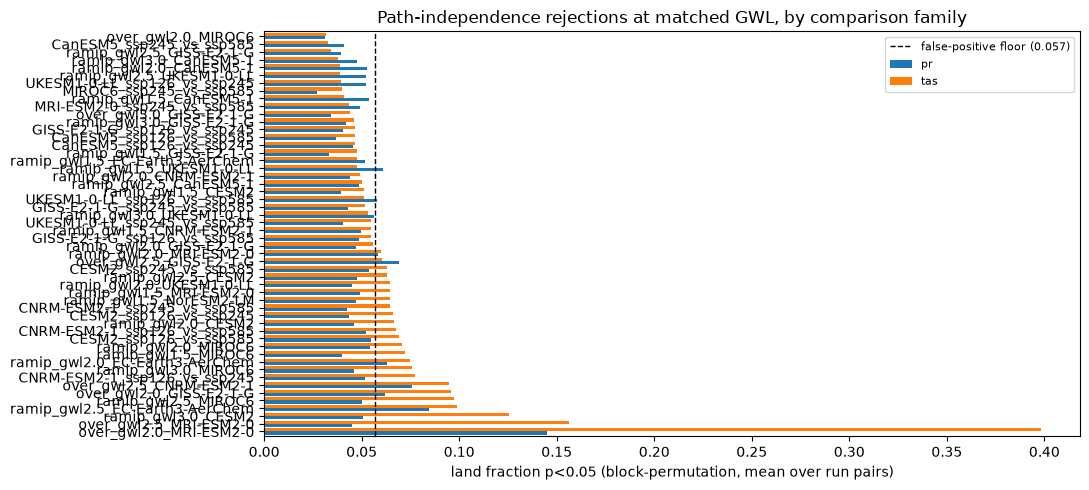

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = (pd.DataFrame(rows).assign(name=lambda d: d.tag)
           .pivot_table(index='name', columns='var', values='land_frac'))
plot_df = plot_df.sort_values('tas' if 'tas' in plot_df else plot_df.columns[0], ascending=False)
plot_df.plot.barh(ax=ax, width=0.8)
ax.axvline(FLOOR, color='k', ls='--', lw=1, label=f'false-positive floor ({FLOOR})')
ax.set_xlabel(f'land fraction p<{ALPHA} (block-permutation, mean over run pairs)')
ax.set_ylabel('')
ax.set_title('Path-independence rejections at matched GWL, by comparison family')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(out_dir + 'ks_scenarios_landfrac.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'ks_scenarios_landfrac.png')

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_scenarios_fracmaps_tas.png


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_scenarios_fracmaps_pr.png


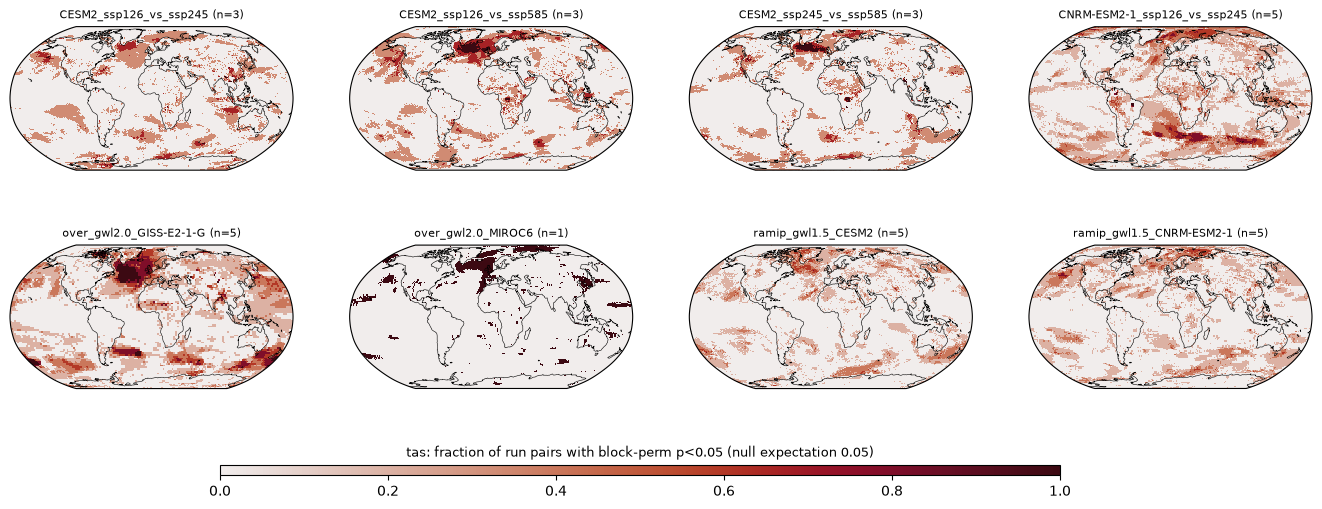

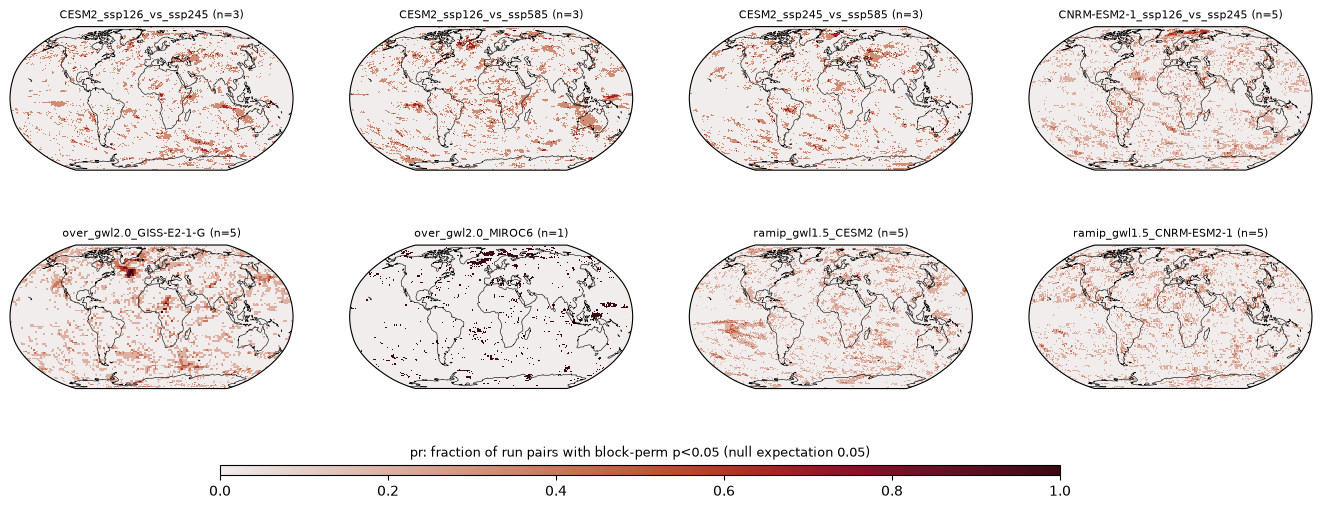

In [9]:
def frac_map(ds):
    return (ds.p_blockperm < ALPHA).mean('pair')


for var in VARS:
    tags = [t for (v, t) in sorted(scen_res) if v == var][:4] + \
           [t for (v, t) in sorted(ov_res) if v == var][:2] + \
           [t for (v, t) in sorted(ramip_res) if v == var][:2]
    if not tags:
        continue
    ncol = 4
    nrow = int(np.ceil(len(tags) / ncol))
    fig, axs = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 2.6 * nrow),
                            subplot_kw={'projection': ccrs.Robinson()}, squeeze=False)
    for ax in axs.flat[len(tags):]:
        ax.set_visible(False)
    for ax, tag in zip(axs.flat, tags):
        ds = {**scen_res, **ov_res, **ramip_res}[(var, tag)]
        f = frac_map(ds)
        im = ax.pcolormesh(f.lon, f.lat, f, cmap=cmocean.cm.amp, vmin=0, vmax=1,
                           transform=ccrs.PlateCarree())
        ax.coastlines(lw=0.4)
        ax.set_title(f'{tag} (n={ds.sizes["pair"]})', fontsize=8)
    cax = fig.add_axes([0.25, -0.02, 0.5, 0.02])
    fig.colorbar(im, cax=cax, orientation='horizontal')
    cax.set_title(f'{var}: fraction of run pairs with block-perm p<{ALPHA} '
                  f'(null expectation {ALPHA})', fontsize=9)
    fig.savefig(out_dir + f'ks_scenarios_fracmaps_{var}.png', dpi=150, bbox_inches='tight')
    print('saved', out_dir + f'ks_scenarios_fracmaps_{var}.png')